## Crop Yield Prediction using Machine Learning


### 1. Introduction

Agriculture plays a crucial role in economic development and food security. Predicting crop yield accurately can help farmers and policymakers make better decisions.

This project aims to use machine learning techniques to analyze agricultural data and predict crop production based on various factors such as area, crop type, season, and location.

### 2.Data Understanding

The main goals of this project are:

- Predict crop production using machine learning models
- Analyze patterns across crops, states, and seasons
- Compare different machine learning algorithms
- Provide insights for data-driven agricultural decisions

### 3.Data Cleaning

In [1]:
# importing necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the dataset

crop_data=pd.read_csv("crop_production.csv")
crop_data.head()

,Year (year),State Name (state_name),State Code (state_code),District Name (district_name),District Code (district_code),Crop Name (crop_name),Crop Code (crop_code),Crop Type (crop_type),Season (season),Area (area),Area Unit (area_unit),Production (production),Production Unit (production_unit),Yield (yield),Yield Unit (yield_unit)
0,2008-2009,Uttarakhand,5,Champawat,48,Other Oilseeds,1088.0,Oilseeds,Kharif,219.0,Hectare,115.0,Tonnes,0.525,Tonnes/Hectare
1,2018-2019,Uttar Pradesh,9,Chitrakoot,136,Onion,708.0,Vegetable,Total,162.0,Hectare,2419.0,Tonnes,14.932,Tonnes/Hectare
2,2015-2016,Chhattisgarh,22,Dhamtari,377,Turmeric,504.0,Spices,Whole Year,2.0,Hectare,4.0,Tonnes,2.000,Tonnes/Hectare
3,2021-2022,Uttar Pradesh,9,Mirzapur,170,Guar Seed,727.0,Vegetable,Kharif,20.0,Hectare,14.0,Tonnes,0.700,Tonnes/Hectare
4,2006-2007,Andhra Pradesh,28,East Godavari,505,Jowar,102.0,Cereals,Kharif,640.0,Hectare,476.0,Tonnes,0.744,Tonnes/Hectare


In [3]:
#rows X columns
crop_data.shape

(500, 15)

In [4]:
# dataset columns
crop_data.columns

Index(['Year (year)', 'State Name (state_name)', 'State Code (state_code)',
       'District Name (district_name)', 'District Code (district_code)',
       'Crop Name (crop_name)', 'Crop Code (crop_code)',
       'Crop Type (crop_type)', 'Season (season)', 'Area (area)',
       'Area Unit (area_unit)', 'Production (production)',
       'Production Unit (production_unit)', 'Yield (yield)',
       'Yield Unit (yield_unit)'],
      dtype='object')

In [5]:
# statistical inference of the dataset
crop_data.describe()

,State Code (state_code),District Code (district_code),Crop Code (crop_code),Area (area),Production (production),Yield (yield)
count,500.000000,500.000000,500.000000,500.000000,4.970000e+02,500.000000
mean,19.380000,359.914000,457.508000,12006.627236,1.276172e+05,38.508634
std,9.555009,191.214111,361.401522,33930.475181,1.512705e+06,568.661198
min,1.000000,4.000000,101.000000,1.000000,0.000000e+00,0.000000
25%,9.000000,190.500000,106.000000,80.750000,8.400000e+01,0.576250
50%,21.000000,363.000000,288.000000,665.500000,1.067600e+03,1.106000
75%,27.250000,524.250000,708.000000,6833.482500,1.117200e+04,2.657750
max,36.000000,763.000000,1302.000000,368360.000000,3.087030e+07,11510.179000


In [6]:
# rename column 
crop_data.columns = [
    'Crop_Year', 'State_Name', 'State_Code',
    'District_Name', 'District_Code',
    'Crop', 'Crop_Code', 'Crop_Type',
    'Season', 'Area', 'Area_Unit',
    'Production', 'Production_Unit',
    'Yield', 'Yield_Unit'
]


In [7]:
#select neccessary columns
df_final = crop_data[[
    'State_Name', 'District_Name', 'Crop_Year',
    'Season', 'Crop', 'Area', 'Production'
]].copy()
df_final

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Uttarakhand,Champawat,2008-2009,Kharif,Other Oilseeds,219.0,115.0
1,Uttar Pradesh,Chitrakoot,2018-2019,Total,Onion,162.0,2419.0
2,Chhattisgarh,Dhamtari,2015-2016,Whole Year,Turmeric,2.0,4.0
3,Uttar Pradesh,Mirzapur,2021-2022,Kharif,Guar Seed,20.0,14.0
4,Andhra Pradesh,East Godavari,2006-2007,Kharif,Jowar,640.0,476.0
...,...,...,...,...,...,...,...
495,Himachal Pradesh,Bilaspur,2018-2019,Whole Year,Sugarcane,3.0,27.0
496,Uttar Pradesh,Sultanpur,2001-2002,Total,Rice,160538.0,358477.0
497,Chhattisgarh,Dhamtari,2015-2016,Rabi,Potato,131.0,1183.0
498,West Bengal,Howrah,2020-2021,Rabi,Maize,67.0,107.0


In [8]:
# understand data types
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     500 non-null    object 
 1   District_Name  500 non-null    object 
 2   Crop_Year      500 non-null    object 
 3   Season         500 non-null    object 
 4   Crop           500 non-null    object 
 5   Area           500 non-null    float64
 6   Production     497 non-null    float64
dtypes: float64(2), object(5)
memory usage: 27.5+ KB


In [9]:
df_final.describe()

,Area,Production
count,500.000000,4.970000e+02
mean,12006.627236,1.276172e+05
std,33930.475181,1.512705e+06
min,1.000000,0.000000e+00
25%,80.750000,8.400000e+01
50%,665.500000,1.067600e+03
75%,6833.482500,1.117200e+04
max,368360.000000,3.087030e+07


In [10]:
# Checking missing values of the dataset in each column
df_final.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       3
dtype: int64

In [11]:
# Dropping missing values 
df_final = df_final.dropna()

In [12]:
# Checking missing values of the dataset in each column
df_final.isnull().values.any()

np.False_

In [13]:
# Displaying State Names present in the dataset
df_final.State_Name.unique()

array(['Uttarakhand', 'Uttar Pradesh', 'Chhattisgarh', 'Andhra Pradesh',
       'Assam', 'Rajasthan', 'Jammu And Kashmir', 'Bihar', 'Karnataka',
       'Tamil Nadu', 'West Bengal', 'Madhya Pradesh', 'Odisha', 'Gujarat',
       'Punjab', 'Manipur', 'Meghalaya', 'Telangana', 'Maharashtra',
       'Jharkhand', 'Tripura', 'Haryana', 'Kerala', 'Sikkim', 'Nagaland',
       'Mizoram', 'Himachal Pradesh', 'Andaman And Nicobar Islands',
       'Arunachal Pradesh', 'Puducherry'], dtype=object)

In [14]:
# Displaying Crop present in the dataset
df_final.Crop.unique()

array(['Other Oilseeds', 'Onion', 'Turmeric', 'Guar Seed', 'Jowar',
       'Wheat', 'Garlic', 'Moong(Green Gram)', 'Potato', 'Sugarcane',
       'Rice', 'Maize', 'Groundnut', 'Arhar/Tur', 'Dry Chillies',
       'Barley', 'Linseed', 'Jute', 'Other Kharif Pulses', 'Cashewnut',
       'Peas & Beans (Pulses)', 'Pome Fruit', 'Sesamum', 'Castor Seed',
       'Urad', 'Bajra', 'Cotton(Lint)', 'Tapioca', 'Cauliflower',
       'Soyabean', 'Tobacco', 'Cowpea(Lobia)', 'Masoor', 'Sannhamp',
       'Other Rabi Pulses', 'Coriander', 'Gram', 'Rapeseed &Mustard',
       'Coconut', 'Ginger', 'Other Vegetables', 'Sunflower',
       'Other Cereals', 'Arecanut', 'Moth', 'Horse-Gram', 'Sweet Potato',
       'Ragi', 'Arcanut (Processed)', 'Papaya', 'Snak Guard',
       'Small Millets', 'Banana', 'Orange', 'Mesta', 'Khesari',
       'Safflower', 'Cardamom', 'Black Pepper', 'Niger Seed', 'Korra'],
      dtype=object)

In [15]:
#The "Crop_Year" column contained values in a range format (e.g., "2008-2009").
#These values were cleaned by extracting the starting year and converting it into a numeric format for machine learning compatibility.

df_final['Crop_Year'] = df_final['Crop_Year'].str.split('-').str[0]
df_final['Crop_Year'] = pd.to_numeric(df_final['Crop_Year'], errors='coerce')

C:\Users\Jemima Kokobe\AppData\Local\Temp\ipykernel_37108\2601618702.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Crop_Year'] = df_final['Crop_Year'].str.split('-').str[0]
C:\Users\Jemima Kokobe\AppData\Local\Temp\ipykernel_37108\2601618702.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Crop_Year'] = pd.to_numeric(df_final['Crop_Year'], errors='coerce')


In [16]:
#display he dataset
df_final.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Uttarakhand,Champawat,2008,Kharif,Other Oilseeds,219.0,115.0
1,Uttar Pradesh,Chitrakoot,2018,Total,Onion,162.0,2419.0
2,Chhattisgarh,Dhamtari,2015,Whole Year,Turmeric,2.0,4.0
3,Uttar Pradesh,Mirzapur,2021,Kharif,Guar Seed,20.0,14.0
4,Andhra Pradesh,East Godavari,2006,Kharif,Jowar,640.0,476.0


### 4.EDA (visualisation)

Text(0.5, 1.0, 'Distribution of Production')

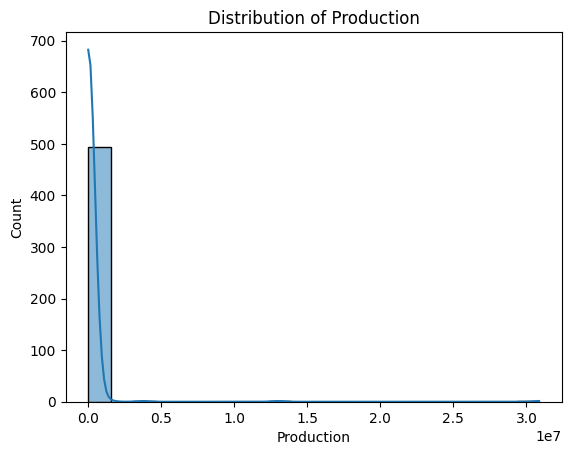

In [17]:
# Plot the distribution of crop production to understand data spread and detect outliers
sns.histplot(df_final["Production"], bins=20,kde=True)
plt.title("Distribution of Production")

##### comment : 
The distribution of production is highly skewed with extreme outliers.

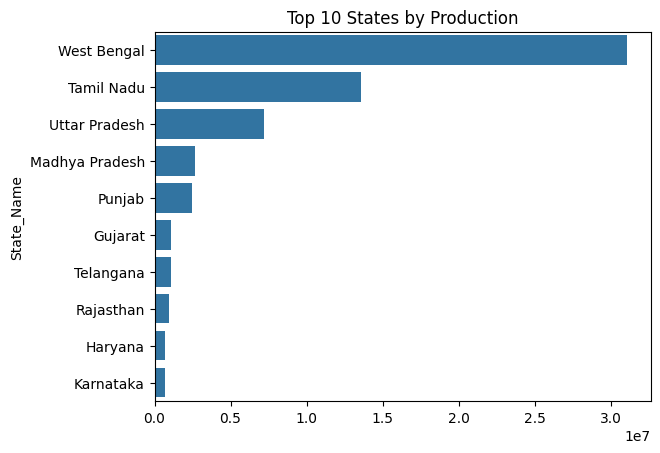

In [18]:
# Group data by state and calculate total production
state_prod = df_final.groupby("State_Name")["Production"].sum().sort_values(ascending=False).head(10)

# Plot top 10 states by production
sns.barplot(x=state_prod.values, y=state_prod.index)
plt.title("Top 10 States by Production")
plt.show()

##### comment:
West Bengal has the highest crop production by a significant margin, followed by Tamil Nadu and Uttar Pradesh. This indicates an uneven distribution of agricultural productivity across states.

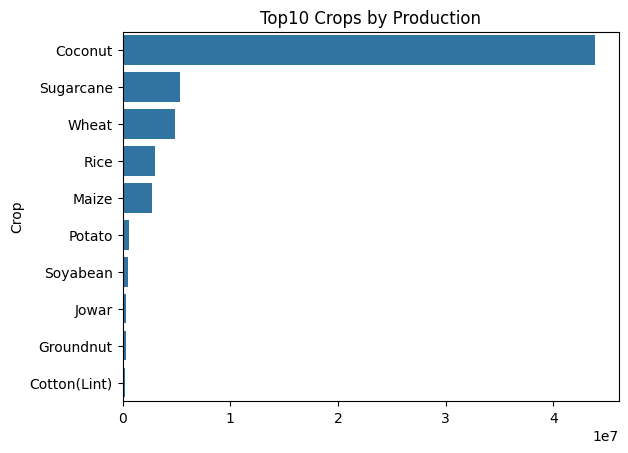

In [19]:
# Group data by crop and calculate total production
crop_prod = df_final.groupby("Crop")["Production"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=crop_prod.values, y=crop_prod.index)
plt.title("Top10 Crops by Production")
plt.show()

##### comment 
Coconut has a significantly higher production compared to other crops, indicating a strong imbalance in the dataset. This may influence model predictions and should be considered during modeling.

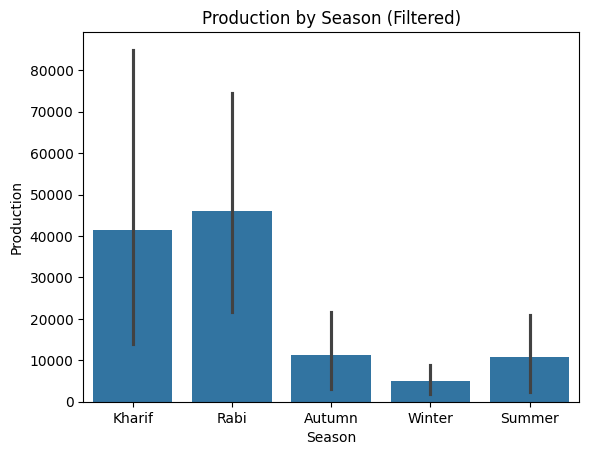

In [20]:
# Filter out non-seasonal categories to keep only real agricultural seasons
df_season = df_final[~df_final['Season'].isin(['Whole Year', 'Total'])]

# Create a bar plot to compare production across seasons
sns.barplot(x="Season", y="Production", data=df_season)
plt.title("Production by Season (Filtered)")
plt.show()

###### comment
After filtering non-seasonal categories, Rabi and Kharif seasons show the highest production levels, indicating their importance in agricultural output. Other seasons contribute less significantly

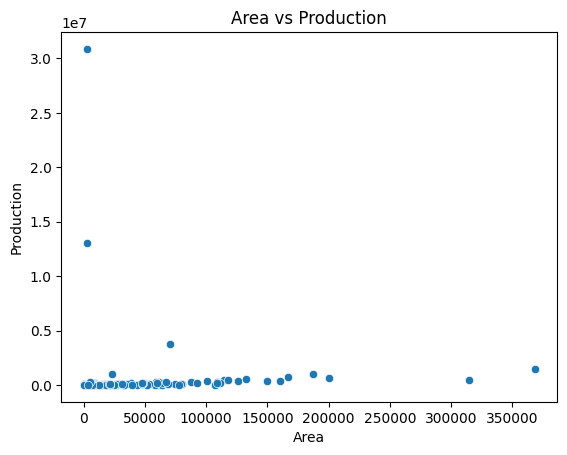

In [21]:
# Create a scatter plot to analyze the relationship between area and production
sns.scatterplot(x="Area", y="Production",data=df_final)
plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production")
plt.show()

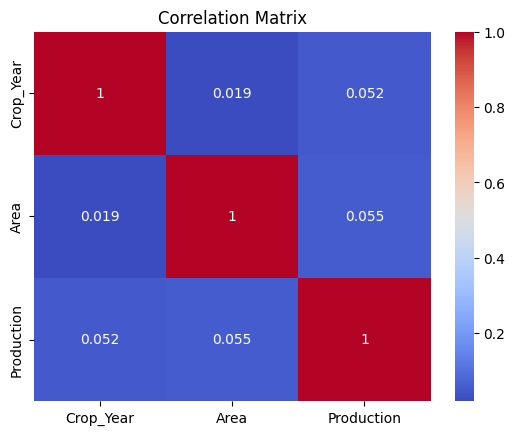

In [22]:
numeric_data = df_final.select_dtypes(include=['number'])

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

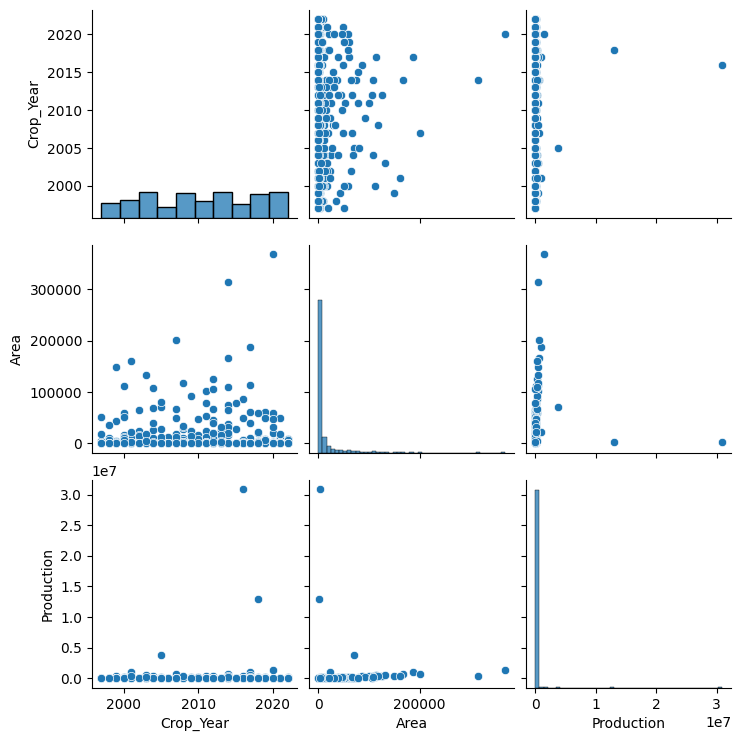

In [23]:
sns.pairplot(df_final)
plt.show()

### 5.Outlier handling 
The exploratory data analysis revealed that both "Area" and "Production" variables are highly skewed with extreme values.

To reduce the impact of these outliers while preserving important information, a log transformation was applied to both variables.

In [24]:
df_model = df_final.copy()

In [25]:
# Apply log transformation to reduce skewness
df_model['Area'] = np.log1p(df_model['Area'])
df_model['Production'] = np.log1p(df_model['Production'])

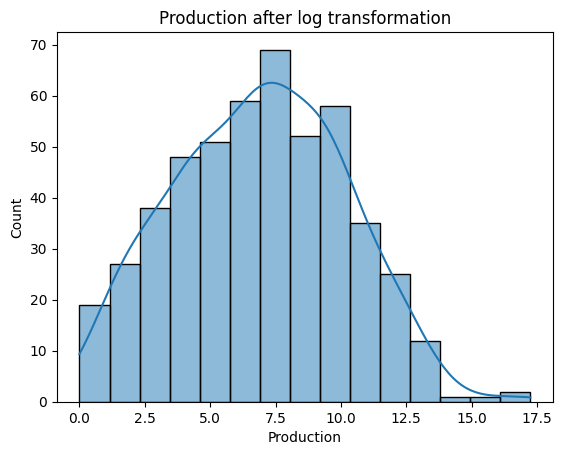

In [26]:
sns.histplot(df_model['Production'], kde=True)
plt.title("Production after log transformation")
plt.show()

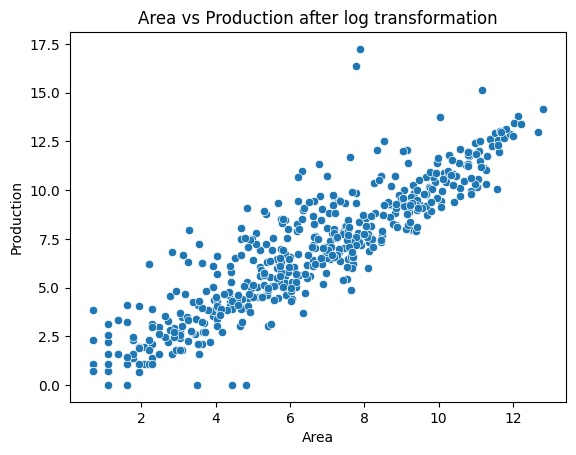

In [27]:
# Create a scatter plot to analyze the relationship between area and production
sns.scatterplot(x="Area", y="Production",data=df_model)
plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production after log transformation")
plt.show()

### 6 Feature Engineering

In [28]:
# Adding a new column Yield which indicates Production per unit Area. 
df_model['Yield'] = (df_model['Production'] / df_model['Area'])
df_model.head() 

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Uttarakhand,Champawat,2008,Kharif,Other Oilseeds,5.393628,4.753590,0.881335
1,Uttar Pradesh,Chitrakoot,2018,Total,Onion,5.093750,7.791523,1.529624
2,Chhattisgarh,Dhamtari,2015,Whole Year,Turmeric,1.098612,1.609438,1.464974
3,Uttar Pradesh,Mirzapur,2021,Kharif,Guar Seed,3.044522,2.708050,0.889483
4,Andhra Pradesh,East Godavari,2006,Kharif,Jowar,6.463029,6.167516,0.954276


### 7.Modeling

In [29]:
# Dropping unnecessary columns
data = df_model.drop(['State_Name', 'District_Name'], axis=1)


In [30]:
# Convert categorical variables
dummy = pd.get_dummies(data)
dummy


,Crop_Year,Area,Production,Yield,Season_Autumn,Season_Kharif,Season_Rabi,Season_Summer,Season_Total,Season_Whole Year,...,Crop_Snak Guard,Crop_Soyabean,Crop_Sugarcane,Crop_Sunflower,Crop_Sweet Potato,Crop_Tapioca,Crop_Tobacco,Crop_Turmeric,Crop_Urad,Crop_Wheat
0,2008,5.393628,4.753590,0.881335,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,5.093750,7.791523,1.529624,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,2015,1.098612,1.609438,1.464974,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,2021,3.044522,2.708050,0.889483,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2006,6.463029,6.167516,0.954276,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2018,1.386294,3.332205,2.403677,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
496,2001,11.986292,12.789623,1.067021,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
497,2015,4.882802,7.076654,1.449302,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
498,2020,4.219508,4.682131,1.109639,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### Train and test

In [31]:

from sklearn.model_selection import train_test_split
# Features and target
x = dummy.drop(["Production", "Yield"], axis=1, errors='ignore')
y = np.log1p(dummy["Production"])

# Splitting data set - 25% test dataset and 75% train

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25, random_state=42)

print("x_train :",x_train.shape)
print("x_test :",x_test.shape)
print("y_train :",y_train.shape)
print("y_test :",y_test.shape)

x_train : (372, 70)
x_test : (125, 70)
y_train : (372,)
y_test : (125,)


In [32]:
print(x_train.head())
print(y_train.head())

     Crop_Year       Area  Season_Autumn  Season_Kharif  Season_Rabi  \
46        2018   7.075809          False           True        False   
31        2017  11.018809          False           True        False   
113       2001   9.258082          False           True        False   
336       2000   4.595120          False          False         True   
276       2006   3.637586          False          False        False   

     Season_Summer  Season_Total  Season_Whole Year  Season_Winter  \
46           False         False              False          False   
31           False         False              False          False   
113          False         False              False          False   
336          False         False              False          False   
276          False         False               True          False   

     Crop_Arcanut (Processed)  ...  Crop_Snak Guard  Crop_Soyabean  \
46                      False  ...            False          False   
31    

#### Linear Regression

In [33]:
# Training the Simple Linear Regression model .

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
lr_predict = model.predict(x_test)
lr_predict

array([1.81909296, 1.4334338 , 1.45476553, 1.15289278, 2.1642394 ,
       2.25125633, 2.30437205, 2.55983603, 2.08470353, 2.10380386,
       2.10954457, 2.40533853, 2.14710078, 1.01199083, 2.5732958 ,
       1.93734543, 2.48040582, 1.63933451, 2.17830993, 2.09324345,
       2.21450054, 1.94625183, 2.72417728, 1.60374755, 2.38886219,
       1.81378336, 2.07781502, 2.15323463, 1.96492804, 1.63124703,
       1.73187957, 1.95346857, 2.37102368, 1.14922017, 2.54281087,
       2.37181609, 2.62832553, 1.18388107, 1.93677461, 2.7518914 ,
       1.85355878, 2.56369337, 1.91780873, 0.99273834, 1.58337819,
       2.26374562, 1.41933194, 2.18787667, 1.65413623, 1.64199782,
       2.11470308, 2.1635626 , 1.65682558, 1.61267628, 2.01578941,
       2.4922483 , 1.95534957, 1.66820837, 1.33838613, 2.50430105,
       2.56978457, 1.77316157, 1.13840238, 2.29015623, 2.34826535,
       2.52317726, 1.19885738, 1.28734554, 2.68199119, 2.65406523,
       2.56699127, 1.97520306, 2.102914  , 1.28876498, 1.29581

##### model evaluation with mse nd r2

In [35]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test, lr_predict)
print("MSE:",mse)
r2 = r2_score(y_test,lr_predict)
print("R2 score :",r2)


MSE: 0.09983323584461741
R2 score : 0.670505308278657


Text(0.5, 1.0, 'Linear Regression')

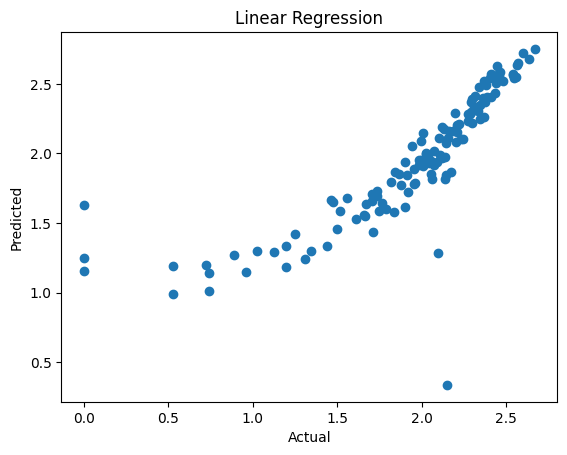

In [36]:
plt.scatter(y_test,lr_predict)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')

#### Random forest algorithm

In [37]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

rf_predict = model.predict(x_test)
rf_predict


array([2.08034982, 1.84131196, 1.5583619 , 0.70724604, 2.25880441,
       2.22562686, 2.31972121, 2.44045583, 1.89492908, 2.19386816,
       2.20047588, 2.28335456, 2.14586777, 0.6630401 , 2.57935314,
       2.05185236, 2.50773739, 1.65786889, 2.14964752, 2.10798758,
       2.23540004, 2.10222519, 2.36136672, 1.89283252, 2.37074969,
       2.13176293, 1.01041963, 2.28375542, 2.31684125, 1.46409497,
       1.83705053, 1.97589048, 2.37716723, 0.94352237, 2.46250051,
       2.41714905, 2.54276171, 1.06493512, 1.97625229, 2.64189235,
       2.14901565, 2.5205541 , 1.83116324, 0.90836909, 1.76253362,
       2.26952713, 1.39612387, 2.16628271, 1.55887628, 1.76463455,
       2.04975235, 2.30278154, 1.72274946, 1.64273695, 1.87599257,
       2.35777903, 1.81563414, 0.92721378, 0.96429809, 2.44674092,
       2.38037606, 1.78536926, 1.18398816, 2.15637435, 2.34384193,
       2.49499336, 1.12007814, 2.17251803, 2.62988663, 2.50547418,
       2.45593239, 2.22669055, 2.2148036 , 1.28516492, 1.29698

##### model evaluation using r2

In [38]:
# Score du modèle
rf_scores = model.score(x_test, y_test)
print("R2 Score :", rf_scores)

R2 Score : 0.7773066421678835


Text(0.5, 1.0, 'Random Forest')

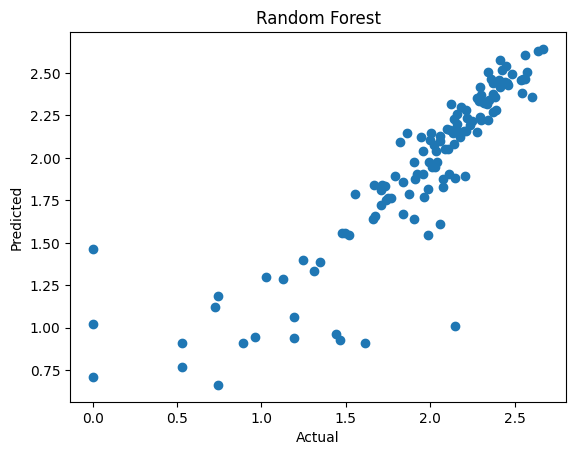

In [39]:
plt.scatter(y_test,rf_predict)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest')

#### Decision tree algorithm

In [40]:
# Training model 
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 5)
regressor.fit(x_train,y_train)

# Predicting results
decisiontree_predict = regressor.predict(x_test)
decisiontree_predict

array([2.07619937, 1.81698716, 1.66847353, 0.52658903, 2.23417605,
       2.34965657, 2.36482608, 2.31569343, 2.02920041, 2.14963432,
       2.16658388, 2.2870719 , 2.25422804, 0.52658903, 2.59712487,
       2.04963148, 2.39154987, 1.58756448, 2.1904016 , 2.23262779,
       2.22567348, 2.17378794, 2.32630125, 1.69208955, 2.3412682 ,
       2.079711  , 0.        , 2.32652849, 2.32652849, 1.57320916,
       1.84028251, 1.88226182, 2.42259548, 0.86974169, 2.42217235,
       2.47636392, 2.52708192, 1.02667203, 1.89708399, 2.61699581,
       2.13431338, 2.49544029, 1.70870183, 1.08041782, 1.90945257,
       2.2870719 , 1.58756448, 2.14963432, 1.39736348, 1.70870183,
       2.10688233, 2.42259548, 1.69208955, 1.79353045, 1.9777599 ,
       2.3412682 , 1.81698716, 0.86974169, 1.16228311, 2.46281106,
       2.51188322, 1.78787422, 1.31050619, 2.17378794, 2.37618546,
       2.52829887, 1.57456514, 2.22603605, 2.61699581, 2.46993144,
       2.5164219 , 2.21367878, 2.30678029, 1.18226788, 1.28421

##### model evaluation using r2

In [41]:
# Score
dt_scores = regressor.score(x_test, y_test)
print("R2 Score:", dt_scores)

R2 Score: 0.6246219482518475


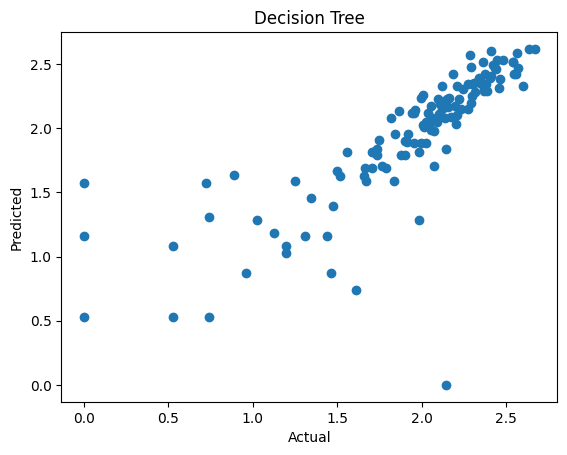

In [42]:
# Plot
plt.scatter(y_test, decisiontree_predict)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Decision Tree')
plt.show()

### 8.cross validation

#### random forest

In [43]:
from sklearn.model_selection import cross_val_score

accuracies = cross_val_score(
    estimator=model,
    X=x_train,
    y=y_train,
    cv=10,
    scoring='r2'   
)

# Mean and standard deviation
mean_score = accuracies.mean()
std_score = accuracies.std()

print("Mean R2 Score: {:.4f}".format(mean_score))
print("Standard Deviation: {:.4f}".format(std_score))

Mean R2 Score: 0.7721
Standard Deviation: 0.1225


#### decision tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

# Model
dt_model = DecisionTreeRegressor(random_state=42)

# Cross-validation
dt_scores = cross_val_score(
    estimator=dt_model,
    X=x_train,
    y=y_train,
    cv=10,
    scoring='r2'
)

# Results
print("Decision Tree Mean R2:", dt_scores.mean())
print("Decision Tree Std:", dt_scores.std())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Récupération automatique des scores
rf_scores = cross_val_score(model, x_train, y_train, cv=10, scoring='r2')
rf_r2 = rf_scores.mean()

dt_scores = cross_val_score(dt_model, x_train, y_train, cv=10, scoring='r2')
dt_r2 = dt_scores.mean()

# Liste des modèles
models = ['Random Forest', 'Decision Tree']

# Liste des scores
r2_scores = [rf_r2, dt_r2]

# Position
x_pos = np.arange(len(models))

# Graphique
plt.figure(figsize=(8,5))
plt.bar(x_pos, r2_scores, color=['#488AC7','#ff8c00'])

plt.xticks(x_pos, models)
plt.ylabel('Mean')
plt.xlabel('Machine Learning Models')
plt.title('Model Comparison (R2 Score)')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Récupération automatique des scores
rf_scores = cross_val_score(model, x_train, y_train, cv=10, scoring='r2')
rf_r2 = rf_scores.std()

dt_scores = cross_val_score(dt_model, x_train, y_train, cv=10, scoring='r2')
dt_r2 = dt_scores.std()

# Liste des modèles
models = ['Random Forest', 'Decision Tree']

# Liste des scores
r2_scores = [rf_r2, dt_r2]

# Position
x_pos = np.arange(len(models))

# Graphique
plt.figure(figsize=(8,5))
plt.bar(x_pos, r2_scores, color=['#488AC7','#ff8c00'])

plt.xticks(x_pos, models)
plt.ylabel('Standrd deviation')
plt.xlabel('Machine Learning Models')
plt.title('Model Comparison (R2 Score)')

plt.show()

### 9.Conclusion